<a href="https://colab.research.google.com/github/ithelga/beeline-banner-ab-test/blob/dev/notebooks/Team1_FinModel_TariffRevenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SmartAds Efficiency**: Оптимизация эффективности маркетинговых каналов

## [STAGE 5] **Подготовка к питч-деку**

Этот ноутбук строит простую финансовую модель на основе результатов кампании:
мы берем число пользователей, которые сменили тариф, и умножаем его на задаваемый вручную
прирост выручки от одной смены тарифа.

Дальше можно смотреть:
- дополнительную выручку по всей кампании;
- дополнительную выручку по сегментам (OS, тип устройства, placement, география);
- как меняются выводы при разных значениях прироста выручки.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

colors = ["#282828", "#F5C341", "#FFDB7D", "#F0F0F0", "#FFFFFF"]  # Основная палитра

# Базовые пути
data_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/data'
graph_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/graph'

# Глобальные настройки оформления графиков
plt.rcParams['figure.facecolor'] = colors[3]   # фон вокруг области построения
plt.rcParams['axes.facecolor'] = colors[4]     # фон внутри графика
plt.rcParams['axes.edgecolor'] = colors[0]     # рамка графика

plt.rcParams['text.color'] = colors[0]         # общий цвет текста
plt.rcParams['axes.labelcolor'] = colors[0]    # подписи осей
plt.rcParams['xtick.color'] = colors[0]        # подписи по оси X
plt.rcParams['ytick.color'] = colors[0]        # подписи по оси Y


Mounted at /content/drive


## 1. Загрузка данных

Используем ту же витрину `supertable`, что и в EDA.


In [ ]:
supertable = pd.read_csv(f"{data_path}/supertable.csv")
supertable.head()

,user_id,timestamp,date,shows,clicks,banner_first,campaign_first,placement,device_type,os,geo,has_install_event,has_first_order_event,has_registration_event,has_tariff_switch_event,segment,tariff,creative_type,size,target_audience_segment
0,1,2025-02-10 10:06:23,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
1,1,2025-02-15 20:05:59,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
2,1,2025-02-16 08:34:35,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
3,1,2025-02-17 21:55:14,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
4,1,2025-03-01 20:13:19,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression


## 2. Базовые параметры финансовой модели

Единственный варьируемый параметр модели — это **прирост выручки от смены тарифа одним пользователем**.
Например, если база — 300 ₽ в месяц, новый тариф — 450 ₽ в месяц, а горизонт анализа — 3 месяца,
то прирост может быть 150 * 3 = 450 ₽.

Ниже можно задать этот параметр и при желании добавить бюджет кампании,
чтобы посчитать окупаемость (ROI).


In [ ]:
# Прирост выручки от смены тарифа одним пользователем, ₽
delta_revenue_per_switch = 100.0

# При желании можно задать бюджет кампании (общие затраты на показы баннеров), ₽
# Если оставить 0, ROI считаться не будет
total_campaign_cost = 90.0

delta_revenue_per_switch, total_campaign_cost

(100.0, 90.0)

## 3. Дополнительная выручка по всей кампании

In [ ]:
# Число пользователей, сменивших тариф (хотя бы одна смена)
if "has_tariff_switch_event" not in supertable.columns:
    raise ValueError("Витрина не содержит колонку 'has_tariff_switch_event'.")

total_switch_users = (
    supertable.loc[supertable["has_tariff_switch_event"] == 1, "user_id"]
    .nunique()
)

total_extra_revenue = delta_revenue_per_switch * total_switch_users

print(f"Пользователей со сменой тарифа: {total_switch_users}")
print(f"Прирост выручки на одного пользователя: {delta_revenue_per_switch:.0f} ₽")
print(f"Итого дополнительная выручка кампании: {total_extra_revenue:,.0f} ₽".replace(",", " "))


if total_campaign_cost > 0:
    roi = (total_extra_revenue - total_campaign_cost) / total_campaign_cost
    print(f"Бюджет кампании: {total_campaign_cost:,.0f} ₽".replace(",", " "))
    print(f"ROI кампании: {roi:.2%}")
else:
    print("Бюджет кампании не задан (total_campaign_cost = 0) — ROI не считаем.")

Пользователей со сменой тарифа: 1217
Прирост выручки на одного пользователя: 100 ₽
Итого дополнительная выручка кампании: 121 700 ₽
Бюджет кампании: 90 ₽
ROI кампании: 135122.22%


## 4. Агрегация и выручка по сегментам

In [ ]:
def segment_stats(df, group_col):
    grouped = df.groupby(group_col)

    base = grouped.agg(
        users=("user_id", "nunique"),
        shows=("shows", "sum"),
        clicks=("clicks", "sum"),
    ).reset_index()

    def unique_with_flag(g, flag_col):
        if flag_col not in g.columns:
            return np.nan
        return g.loc[g[flag_col] == 1, "user_id"].nunique()

    extras = grouped.apply(
        lambda g: pd.Series(
            {
                "has_install": unique_with_flag(g, "has_install_event"),
                "has_registration": unique_with_flag(g, "has_registration_event"),
                "has_first_order": unique_with_flag(g, "has_first_order_event"),
                "has_tariff_switch": unique_with_flag(g, "has_tariff_switch_event"),
            }
        )
    ).reset_index()

    stats = base.merge(extras, on=group_col)

    stats["ctr"] = stats["clicks"] / stats["shows"]
    stats["cr_inst_reg"] = stats["has_registration"] / stats["has_install"]
    stats["cr_reg_ord"] = stats["has_first_order"] / stats["has_registration"]
    stats["cr_reg_sw"] = stats["has_tariff_switch"] / stats["has_registration"]
    stats["cr_all"] = stats["has_tariff_switch"] / stats["shows"]

    return stats

In [ ]:
def revenue_by_segment(df, group_col, delta):
    stats = segment_stats(df, group_col)
    stats["switch_users"] = stats["has_tariff_switch"]
    stats["extra_revenue"] = stats["switch_users"] * delta
    stats["extra_rev_per_1000_shows"] = stats["extra_revenue"] / stats["shows"] * 1000

    cols = [group_col, "users", "shows", "switch_users", "extra_revenue", "extra_rev_per_1000_shows"]
    return stats[cols].sort_values("extra_revenue", ascending=False)

### 4.1. Выручка по ключевым срезам

Ниже — таблицы по дополнительной выручке в зависимости от выбранного значения
`delta_revenue_per_switch`. Чтобы посмотреть чувствительность модели, достаточно
изменить это значение выше и перезапустить ячейки.


In [ ]:
# OS
if "os" in supertable.columns:
    print("\nДополнительная выручка по OS")
    os_rev = revenue_by_segment(supertable, "os", delta_revenue_per_switch)
    display(os_rev)

# Placement
if "placement" in supertable.columns:
    print("\nДополнительная выручка по placement")
    placement_rev = revenue_by_segment(supertable, "placement", delta_revenue_per_switch)
    display(placement_rev)

# Тип устройства
if "device_type" in supertable.columns:
    print("\nДополнительная выручка по типу устройства")
    device_rev = revenue_by_segment(supertable, "device_type", delta_revenue_per_switch)
    display(device_rev)

# География (топ-10 по дополнительной выручке)
if "geo" in supertable.columns:
    print("\nДополнительная выручка по географии (топ-10)")
    geo_rev = revenue_by_segment(supertable, "geo", delta_revenue_per_switch)
    display(geo_rev.head(10))


Дополнительная выручка по OS


,os,users,shows,switch_users,extra_revenue,extra_rev_per_1000_shows
0,android,639,763,105,10500.0,13761.467890
1,ios,670,920,97,9700.0,10543.478261
2,web,130,132,17,1700.0,12878.787879



Дополнительная выручка по placement


,placement,users,shows,switch_users,extra_revenue,extra_rev_per_1000_shows
0,app,562,679,96,9600.0,14138.438881
1,site,591,744,81,8100.0,10887.096774
2,social,321,392,44,4400.0,11224.489796



Дополнительная выручка по типу устройства


,device_type,users,shows,switch_users,extra_revenue,extra_rev_per_1000_shows
0,phone,1142,1529,182,18200.0,11903.204709
1,tablet,243,286,37,3700.0,12937.062937



Дополнительная выручка по географии (топ-10)


,geo,users,shows,switch_users,extra_revenue,extra_rev_per_1000_shows
2,Москва,436,522,68,6800.0,13026.819923
8,Санкт-Петербург,195,223,27,2700.0,12107.623318
4,Новосибирск,145,164,23,2300.0,14024.390244
6,Ростов-на-Дону,153,167,21,2100.0,12574.850299
5,Омск,145,181,17,1700.0,9392.265193
9,Челябинск,91,107,15,1500.0,14018.691589
1,Казань,84,102,14,1400.0,13725.490196
0,Екатеринбург,96,118,14,1400.0,11864.406780
3,Нижний Новгород,100,122,14,1400.0,11475.409836
7,Самара,94,109,8,800.0,7339.449541


## 5. Сценарный анализ по разным значениям прироста выручки

Для наглядности можно задать несколько сценариев по `delta_revenue_per_switch`
и посмотреть, как меняется итоговая дополнительная выручка кампании.


,delta_revenue_per_switch,total_extra_revenue
0,50,60850
1,100,121700
2,150,182550
3,200,243400


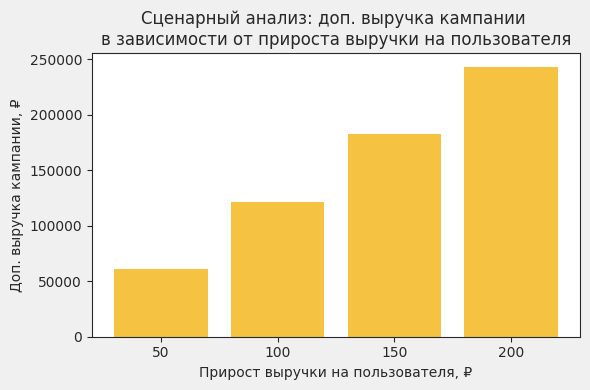

In [ ]:
scenario_values = [50, 100, 150, 200]  # ₽ на одного пользователя со сменой тарифа

rows = []
total_switch_users = (
    supertable.loc[supertable["has_tariff_switch_event"] == 1, "user_id"]
    .nunique()
)

for delta in scenario_values:
    total_extra_rev = delta * total_switch_users
    rows.append({"delta_revenue_per_switch": delta, "total_extra_revenue": total_extra_rev})

scenario_df = pd.DataFrame(rows)
display(scenario_df)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(colors[3])
ax.set_facecolor(colors[4])

ax.bar(
    scenario_df["delta_revenue_per_switch"].astype(str),
    scenario_df["total_extra_revenue"],
    color=colors[1],
)
ax.set_title("Сценарный анализ: доп. выручка кампании \nв зависимости от прироста выручки на пользователя")
ax.set_xlabel("Прирост выручки на пользователя, ₽")
ax.set_ylabel("Доп. выручка кампании, ₽")
plt.tight_layout()
plt.savefig(f'{graph_path}/scenarios_extra_revenue.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

## 6. Как использовать этот калькулятор

1. Задайте значение `delta_revenue_per_switch` в рублях (прирост выручки от смены тарифа одним пользователем).
2. При желании укажите `total_campaign_cost`, чтобы получить оценку ROI по всей кампании.
3. Перезапустите ячейки с расчётами:
   - блок 3 (общая выручка),
   - блок 4 (выручка по сегментам),
   - блок 5 (сценарный анализ).
4. Сравнивайте сегменты между собой по показателям `extra_revenue` и `extra_rev_per_1000_shows`
   и используйте эти результаты вместе с CTR/конверсиями из EDA для выбора приоритетных гипотез и направлений масштабирования кампании.


## 7. Расчёт бюджета кампаний и ROI на основе `daily_budget`

В исходных данных по кампаниям есть таблица с дневным бюджетом `daily_budget` в разрезе `campaign_id`
и датами `start_date` / `end_date`. На её основе можно посчитать:

- общий бюджет каждой кампании;
- суммарные затраты на все кампании за период;
- приблизительную стоимость одного показа (cost per show);
- ROI как по кампании в целом, так и по отдельным сегментам (OS, placement, device, geo).

Ниже мы строим такой расчёт и связываем его с уже рассчитанной дополнительной выручкой от смены тарифа.


In [ ]:
# 7.1. Загрузка таблицы бюджетов кампаний

campaign_budget = pd.read_csv(
    f"{data_path}/CD_campaign.csv", sep=";",
    parse_dates=["start_date", "end_date"],
    dayfirst=True
)

display(campaign_budget.head())

# Количество дней в каждой кампании (включая обе границы)
campaign_budget["days"] = (campaign_budget["end_date"] - campaign_budget["start_date"]).dt.days + 1

# Общий бюджет по каждой кампании
campaign_budget["total_budget"] = campaign_budget["daily_budget"] * campaign_budget["days"]

print("Расчёт бюджета по кампаниям:")
display(campaign_budget[["campaign_id", "daily_budget", "days", "total_budget"]])

# Суммарные затраты на все кампании
total_campaign_cost_from_budget = campaign_budget["total_budget"].sum()
print(f"Суммарный бюджет всех кампаний: {total_campaign_cost_from_budget:,.0f} ₽".replace(",", " "))

,campaign_id,daily_budget,start_date,end_date
0,1,175071.43,2025-02-01,2025-03-17
1,2,95601.86,2025-02-01,2025-03-17
2,3,166617.61,2025-02-01,2025-03-17


Расчёт бюджета по кампаниям:


,campaign_id,daily_budget,days,total_budget
0,1,175071.43,45,7878214.35
1,2,95601.86,45,4302083.70
2,3,166617.61,45,7497792.45


Суммарный бюджет всех кампаний: 19 678 090 ₽


### 7.2. Связь бюджета и доп. выручки, пересчёт ROI

Теперь можно пересчитать ROI кампании, используя бюджет из `daily_budget`, а не вручную заданный `total_campaign_cost`.

Ниже мы сравниваем дополнительную выручку от смены тарифа с суммарным бюджетом всех кампаний.


In [ ]:
# Пересчёт общей доп. выручки и ROI на основе бюджета из campaign_budget

# Число пользователей со сменой тарифа (как и раньше)
total_switch_users = (
    supertable.loc[supertable["has_tariff_switch_event"] == 1, "user_id"]
    .nunique()
)
total_extra_revenue = delta_revenue_per_switch * total_switch_users

print(f"Пользователей со сменой тарифа: {total_switch_users}")
print(f"Прирост выручки на одного пользователя: {delta_revenue_per_switch:.0f} ₽")
print(f"Итого дополнительная выручка кампании: {total_extra_revenue:,.0f} ₽".replace(",", " "))

print(f"Суммарный бюджет кампаний (из daily_budget): {total_campaign_cost_from_budget:,.0f} ₽".replace(",", " "))

roi_budget = (total_extra_revenue - total_campaign_cost_from_budget) / total_campaign_cost_from_budget
print(f"ROI кампании (на основе daily_budget): {roi_budget:.2%}")

Пользователей со сменой тарифа: 1217
Прирост выручки на одного пользователя: 100 ₽
Итого дополнительная выручка кампании: 121 700 ₽
Суммарный бюджет кампаний (из daily_budget): 19 678 090 ₽
ROI кампании (на основе daily_budget): -99.38%
